In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [38]:
df = pd.read_csv("fuel_crisis_dataset.csv")

x_data = df["day"].tolist()
y_data = df["estimated_fuel_demand_thousand_liters"].tolist()

TARGET = 10.5

In [39]:
def lagrange_basis(i, x_nodes, x):
    n       = len(x_nodes)
    Li      = 1.0
 
    for j in range(n):
        if j == i:
            continue
        numerator   = x - x_nodes[j]
        denominator = x_nodes[i] - x_nodes[j]
        Li          = Li * (numerator / denominator)
 
    return Li

In [40]:
def lagrange_interpolate(x_nodes, y_nodes, x):
    n = len(x_nodes)
    result = 0.0
 
    for i in range(n):
        Li      = lagrange_basis(i, x_nodes, x)
        result  = result + y_nodes[i] * Li
 
    return result

In [41]:
def get_closest_nodes(x_data, y_data, target, num_nodes):

    distances = [(abs(x_data[i] - target), x_data[i], y_data[i])
                 for i in range(len(x_data))]
 
    distances.sort(key=lambda t: t[0])
 
    x_nodes = [d[1] for d in distances[:num_nodes]]
    y_nodes = [d[2] for d in distances[:num_nodes]]
 
    return x_nodes, y_nodes
 

In [42]:
print("=" * 60)
print("  Lagrange Interpolation  –  Estimating f(3.5)")
print("=" * 60)
 
previous_value   = None
results_table    = []
 
for k in range(2, 7):
    num_nodes = k + 1
 
    x_nodes, y_nodes = get_closest_nodes(x_data, y_data, TARGET, num_nodes)
 
    pk_value = lagrange_interpolate(x_nodes, y_nodes, TARGET)
 
    if previous_value is None:
        delta = "   –  "
    else:
        delta = f"{abs(pk_value - previous_value):.8f}"
 
    print(f"\n--- P{k}(x)  (degree {k}, using {num_nodes} nodes) ---")
    print(f"  Nodes chosen (sorted by distance from {TARGET}):")
    print(f"  x-nodes : {x_nodes}")
    print(f"  y-nodes : {y_nodes}")
 
    print(f"  Lagrange basis values Li({TARGET}):")
    for i in range(num_nodes):
        Li_val = lagrange_basis(i, x_nodes, TARGET)
        print(f"    L{i}({TARGET}) = {Li_val:.8f}")
 
    print(f"  P{k}({TARGET}) = {pk_value:.8f}")
    print(f"  Δ{k}          = {delta}")
 
    results_table.append((k, pk_value, delta))
    previous_value = pk_value

  Lagrange Interpolation  –  Estimating f(3.5)

--- P2(x)  (degree 2, using 3 nodes) ---
  Nodes chosen (sorted by distance from 10.5):
  x-nodes : [10, 11, 9]
  y-nodes : [1574.393, 1503.682, 1604.872]
  Lagrange basis values Li(10.5):
    L0(10.5) = 0.75000000
    L1(10.5) = 0.37500000
    L2(10.5) = -0.12500000
  P2(10.5) = 1544.06650000
  Δ2          =    –  

--- P3(x)  (degree 3, using 4 nodes) ---
  Nodes chosen (sorted by distance from 10.5):
  x-nodes : [10, 11, 9, 12]
  y-nodes : [1574.393, 1503.682, 1604.872, 1433.957]
  Lagrange basis values Li(10.5):
    L0(10.5) = 0.56250000
    L1(10.5) = 0.56250000
    L2(10.5) = -0.06250000
    L3(10.5) = -0.06250000
  P3(10.5) = 1541.49037500
  Δ3          = 2.57612500

--- P4(x)  (degree 4, using 5 nodes) ---
  Nodes chosen (sorted by distance from 10.5):
  x-nodes : [10, 11, 9, 12, 8]
  y-nodes : [1574.393, 1503.682, 1604.872, 1433.957, 1572.051]
  Lagrange basis values Li(10.5):
    L0(10.5) = 0.70312500
    L1(10.5) = 0.46875000
 

In [43]:
print("\n" + "=" * 60)
print("  Convergence Summary Table")
print("=" * 60)
print(f"{'Degree k':<12} {'Pk(3.5)':<22} {'Δk = |Pk - Pk-1|'}")
print("-" * 60)
for (k, val, delta) in results_table:
    print(f"  P{k}        {val:<22.8f} {delta}")
print("=" * 60)


  Convergence Summary Table
Degree k     Pk(3.5)                Δk = |Pk - Pk-1|
------------------------------------------------------------
  P2        1544.06650000             –  
  P3        1541.49037500          2.57612500
  P4        1541.91576562          0.42539062
  P5        1541.59166016          0.32410547
  P6        1541.64763184          0.05597168


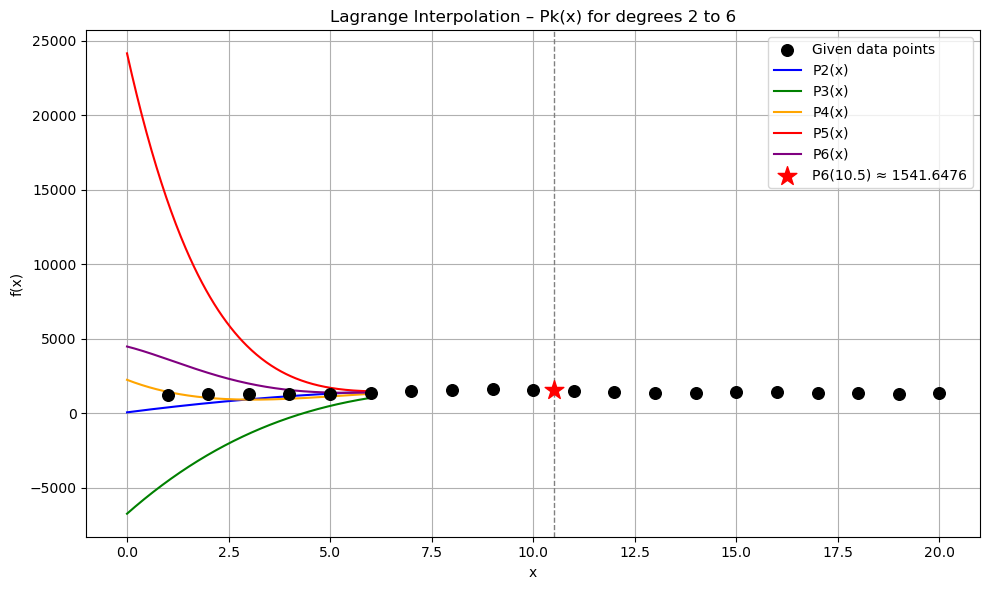


Plot saved as  Lagrange_plot.png


In [44]:
x_plot = np.linspace(0, 6, 300)
 
plt.figure(figsize=(10, 6))
 
plt.scatter(x_data, y_data, color='black', zorder=5,
            label='Given data points', s=70)
 
colors = ['blue', 'green', 'orange', 'red', 'purple']
for idx, (k, val, delta) in enumerate(results_table):
    num_nodes = k + 1
    x_nodes, y_nodes = get_closest_nodes(x_data, y_data, TARGET, num_nodes)
 
    y_plot = [lagrange_interpolate(x_nodes, y_nodes, xi) for xi in x_plot]
 
    plt.plot(x_plot, y_plot, color=colors[idx], label=f'P{k}(x)')
 
best_val = results_table[-1][1]
plt.axvline(x=TARGET, color='gray', linestyle='--', linewidth=1)
plt.scatter([TARGET], [best_val], color='red', zorder=6,
            marker='*', s=200, label=f'P6({TARGET}) ≈ {best_val:.4f}')
 
plt.title("Lagrange Interpolation – Pk(x) for degrees 2 to 6")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Lagrange_plot.png", dpi=150)
plt.show()
print("\nPlot saved as  Lagrange_plot.png")